In [1]:
#Import Required Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [2]:
#Load Dataset (CIFAR-10)
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Normalize pixel values
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# CIFAR-10 has 10 classes
num_classes = 10

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [3]:
#Load Pre-trained CNN Model (MobileNetV2)
base_model = keras.applications.MobileNetV2(
    input_shape=(32, 32, 3),
    include_top=False,       # Exclude final classifier
    weights='imagenet'       # Use pretrained ImageNet weights
)

# Freeze the base model layers (don't train them yet)
for layer in base_model.layers:
    layer.trainable = False


/tmp/ipython-input-4022944354.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
#Add Custom Classifier Layers
model = models.Sequential([
    base_model,                                 # Pretrained feature extractor
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')  # Output layer
])

In [5]:
#Compile the Model
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


In [6]:
#Train Classifier Layers
history = model.fit(x_train, y_train,
                    validation_split=0.1,
                    epochs=5,
                    batch_size=64,
                    verbose=1)


Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 59s 75ms/step - accuracy: 0.2462 - loss: 2.0825 - val_accuracy: 0.3278 - val_loss: 1.8706
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 71ms/step - accuracy: 0.3102 - loss: 1.8917 - val_accuracy: 0.3370 - val_loss: 1.8374
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 66ms/step - accuracy: 0.3256 - loss: 1.8553 - val_accuracy: 0.3462 - val_loss: 1.8161
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 69ms/step - accuracy: 0.3354 - loss: 1.8329 - val_accuracy: 0.3498 - val_loss: 1.8024
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 67ms/step - accuracy: 0.3396 - loss: 1.8200 - val_accuracy: 0.3516 - val_loss: 1.7954


In [7]:
#Evaluate Model Performance
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\n Test Accuracy: {test_acc:.4f}")
print(f" Test Loss: {test_loss:.4f}")



 Test Accuracy: 0.3391
 Test Loss: 1.8191


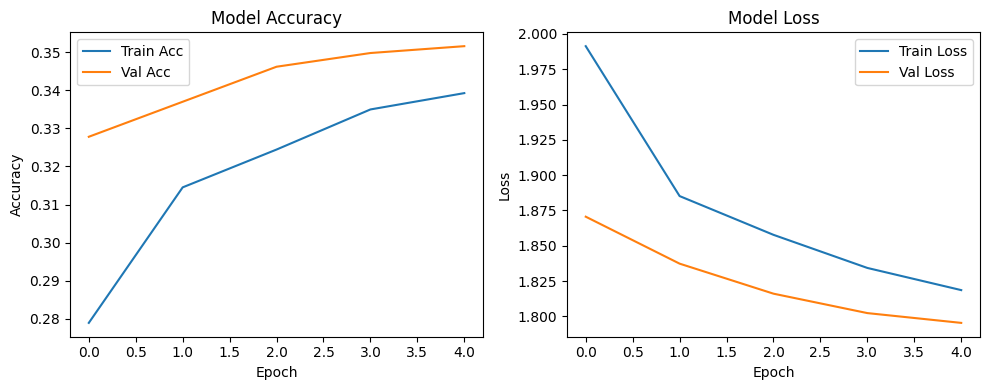

In [8]:
#Plot Accuracy and Loss
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()